# **1. Installation & Imports**

In [1]:
! pip install rasterio  
! pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.5 MB/s eta 0:00:0000:01


In [2]:
import os
import numpy as np
import rasterio
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim
import segmentation_models_pytorch as smp

# **2. Load Pretrained Model**

In [3]:
# DeepLabV3 with EfficientNet-b7 backbone
model = smp.DeepLabV3(
    encoder_name="efficientnet-b7",
    encoder_weights="imagenet",       # pretrained
    in_channels=15,                   # the satellite bands after adding the 3 channels (NDWI, MNDWI, AWEI)
    classes=1                         # binary segmentation
)

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/267M [00:00<?, ?B/s]

# **3. Load & Match Dataset**

In [4]:
IMAGES_PATH = "/kaggle/input/datasets/mahmoudosamahassan/satellite-dataset/satalite data/data/images"
LABELS_PATH = "/kaggle/input/datasets/mahmoudosamahassan/satellite-dataset/satalite data/data/labels"

image_files = sorted(os.listdir(IMAGES_PATH))
label_files = sorted(os.listdir(LABELS_PATH))

print("Number of images:", len(image_files))
print("Number of labels:", len(label_files))


image_ids = set([f.split('.')[0] for f in image_files])
label_ids = set([f.split('.')[0] for f in label_files])

common_ids = sorted(list(image_ids.intersection(label_ids)))

matched_images = [f"{i}.tif" for i in common_ids]
matched_labels = [f"{i}.png" for i in common_ids]
print("Number of matching files:", len(common_ids))

Number of images: 306
Number of labels: 456
Number of matching files: 306


# **4. Read Images & Masks with Spectral Indices**

In [5]:
X = []
Y = []

for img_file, lbl_file in zip(matched_images, matched_labels):

    with rasterio.open(os.path.join(IMAGES_PATH, img_file)) as src:
        img = src.read()  # (bands,H,W)
        img = np.transpose(img, (1,2,0)).astype(np.float32)

    # Band indices
    GREEN = img[:,:,2]
    NIR   = img[:,:,4]
    SWIR1 = img[:,:,5]
    SWIR2 = img[:,:,6]

    # NDWI
    ndwi = (GREEN - NIR) / (GREEN + NIR + 1e-8)

    # MNDWI
    mndwi = (GREEN - SWIR1) / (GREEN + SWIR1 + 1e-8)

    # AWEI
    awei = 4*(GREEN - SWIR1) - (0.25*NIR + 2.75*SWIR2)

    indices = np.stack([ndwi, mndwi, awei], axis=-1)

    # Add indices to image
    img = np.concatenate([img, indices], axis=-1)

    lbl = np.array(Image.open(os.path.join(LABELS_PATH, lbl_file)))
    lbl = np.expand_dims(lbl, axis=-1).astype(np.float32)

    X.append(img)
    Y.append(lbl)

X = np.array(X)
Y = np.array(Y)

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


In [6]:
print("Water pixel ratio:", np.mean(Y))

Water pixel ratio: 0.25975287


# **5. DATA (Train / Val) Split**

In [7]:
X_train, X_val, Y_train, Y_val = train_test_split(
    X,
    Y,
    test_size=0.2,   # 20% validation
    random_state=42,
    shuffle=True
)

print(X_train.shape)
print(X_val.shape)

(244, 128, 128, 15)
(62, 128, 128, 15)


# **6. Band Normalization (Training Statistics Only)**

In [8]:
num_bands = X_train.shape[-1]

band_mins = np.zeros(num_bands)
band_maxs = np.zeros(num_bands)

for b in range(num_bands):
    band_mins[b] = np.min(X_train[..., b])
    band_maxs[b] = np.max(X_train[..., b])

print("Band mins:", band_mins)
print("Band maxs:", band_maxs)

Band mins: [-1.39300000e+03 -1.16900000e+03 -7.22000000e+02 -6.84000000e+02
 -4.12000000e+02 -3.35000000e+02 -2.51000000e+02  6.40000000e+01
 -9.99900000e+03  8.00000000e+00  1.00000000e+01  0.00000000e+00
 -1.42000005e+10 -2.61000000e+02 -6.81295000e+04]
Band maxs: [6.56800000e+03 9.65900000e+03 1.13680000e+04 1.20410000e+04
 1.58410000e+04 1.52520000e+04 1.46470000e+04 2.55000000e+02
 4.24500000e+03 4.28700000e+03 1.00000000e+02 1.11000000e+02
 2.65999995e+10 1.36000000e+10 3.00797500e+04]


In [9]:
def normalize_per_band(X, band_mins, band_maxs): # Min-Max normalization
    X_norm = np.zeros_like(X, dtype=np.float32)

    for b in range(X.shape[-1]):
        X_norm[..., b] = (
            (X[..., b] - band_mins[b]) /
            (band_maxs[b] - band_mins[b] + 1e-8)
        )

    return X_norm

In [10]:
X_train = normalize_per_band(X_train, band_mins, band_maxs)
X_val   = normalize_per_band(X_val, band_mins, band_maxs)

print("After normalization:")
print("Train min/max:", X_train.min(), X_train.max())

After normalization:
Train min/max: 0.0 1.0


# **7. Metrics & PyTorch Data Pipeline**

In [11]:
def iou_score(outputs, masks):
    preds = torch.sigmoid(outputs) > 0.5
    masks = masks.bool()

    intersection = (preds & masks).float().sum()
    union = (preds | masks).float().sum()

    return (intersection + 1e-7) / (union + 1e-7)


def f1_score(outputs, masks):
    preds = torch.sigmoid(outputs) > 0.5
    masks = masks.bool()

    tp = (preds & masks).float().sum()
    fp = (preds & (~masks)).float().sum()
    fn = ((~preds) & masks).float().sum()

    precision = tp / (tp + fp + 1e-7)
    recall = tp / (tp + fn + 1e-7)

    return 2 * precision * recall / (precision + recall + 1e-7)

In [12]:
# Move channel dimension
X_train_torch = torch.tensor(X_train).permute(0, 3, 1, 2).float()
Y_train_torch = torch.tensor(Y_train).permute(0, 3, 1, 2).float()

X_val_torch = torch.tensor(X_val).permute(0, 3, 1, 2).float()
Y_val_torch = torch.tensor(Y_val).permute(0, 3, 1, 2).float()

print(X_train_torch.shape)
print(Y_train_torch.shape)

torch.Size([244, 15, 128, 128])
torch.Size([244, 1, 128, 128])


In [13]:
class WaterDataset(Dataset):
    def __init__(self, images, masks):
        self.images = images
        self.masks = masks

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.masks[idx]

In [14]:
BATCH_SIZE = 8

train_dataset = WaterDataset(X_train_torch, Y_train_torch)
val_dataset = WaterDataset(X_val_torch, Y_val_torch)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [15]:
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [16]:
train_losses = []
val_losses = []

train_ious = []
val_ious = []

train_f1s = []
val_f1s = []

# **8. Training Loop**

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
EPOCHS = 40

for epoch in range(EPOCHS):

    # ===== TRAIN =====
    model.train()
    train_loss = 0
    train_iou = 0
    train_f1 = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_iou += iou_score(outputs, masks).item()
        train_f1 += f1_score(outputs, masks).item()

    train_loss /= len(train_loader)
    train_iou /= len(train_loader)
    train_f1 /= len(train_loader)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0
    val_iou = 0
    val_f1 = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            val_loss += loss.item()
            val_iou += iou_score(outputs, masks).item()
            val_f1 += f1_score(outputs, masks).item()

    val_loss /= len(val_loader)
    val_iou /= len(val_loader)
    val_f1 /= len(val_loader)

    # ===== STORE HISTORY =====
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_ious.append(train_iou)
    val_ious.append(val_iou)

    train_f1s.append(train_f1)
    val_f1s.append(val_f1)

    # ===== PRINT =====
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | IoU: {train_iou:.4f} | F1: {train_f1:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | IoU: {val_iou:.4f} | F1: {val_f1:.4f}")


Epoch 1/40
Train Loss: 0.5935 | IoU: 0.4439 | F1: 0.6001
Val   Loss: 0.7835 | IoU: 0.2114 | F1: 0.3451

Epoch 2/40
Train Loss: 0.4541 | IoU: 0.5373 | F1: 0.6868
Val   Loss: 0.6296 | IoU: 0.1508 | F1: 0.2526

Epoch 3/40
Train Loss: 0.3857 | IoU: 0.5662 | F1: 0.7136
Val   Loss: 0.5076 | IoU: 0.0958 | F1: 0.1598

Epoch 4/40
Train Loss: 0.3187 | IoU: 0.6291 | F1: 0.7645
Val   Loss: 0.5208 | IoU: 0.1623 | F1: 0.2634

Epoch 5/40
Train Loss: 0.3473 | IoU: 0.5786 | F1: 0.7163
Val   Loss: 0.4753 | IoU: 0.1032 | F1: 0.1838

Epoch 6/40
Train Loss: 0.2908 | IoU: 0.6360 | F1: 0.7706
Val   Loss: 0.5830 | IoU: 0.3136 | F1: 0.4650

Epoch 7/40
Train Loss: 0.2782 | IoU: 0.6462 | F1: 0.7777
Val   Loss: 0.4366 | IoU: 0.2872 | F1: 0.4291

Epoch 8/40
Train Loss: 0.2578 | IoU: 0.6594 | F1: 0.7882
Val   Loss: 0.4243 | IoU: 0.2795 | F1: 0.4231

Epoch 9/40
Train Loss: 0.2576 | IoU: 0.6602 | F1: 0.7884
Val   Loss: 0.3666 | IoU: 0.3960 | F1: 0.5542

Epoch 10/40
Train Loss: 0.2573 | IoU: 0.6512 | F1: 0.7800
Val  

# **9. Save & Visualize**

In [18]:
torch.save({
    "model_state_dict": model.state_dict(),
    "band_mins": band_mins,
    "band_maxs": band_maxs
}, "water_model.pth")

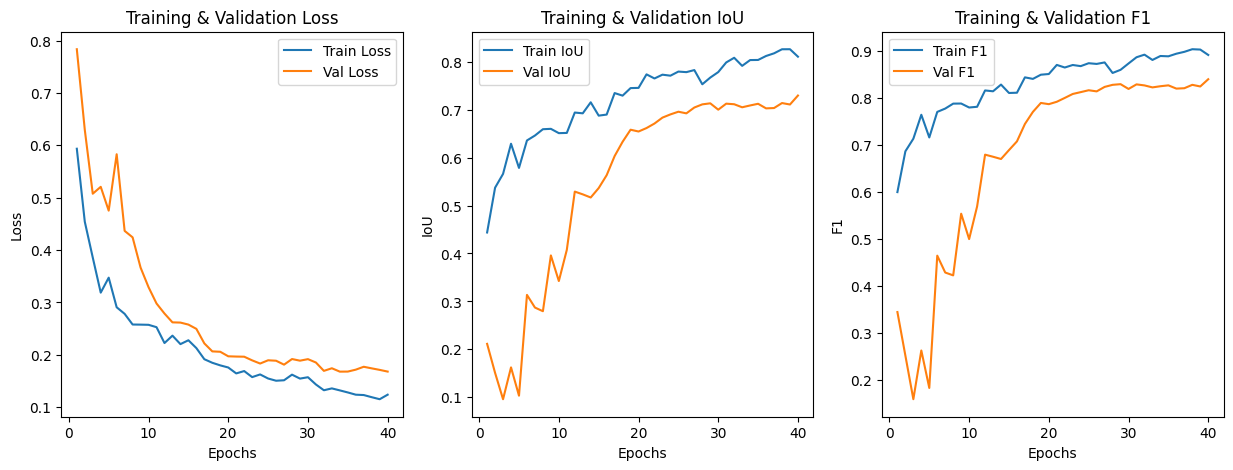

In [19]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(15,5))

# ---- Loss ----
plt.subplot(1,3,1)
plt.plot(epochs, train_losses)
plt.plot(epochs, val_losses)
plt.title("Training & Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train Loss", "Val Loss"])

# ---- IoU ----
plt.subplot(1,3,2)
plt.plot(epochs, train_ious)
plt.plot(epochs, val_ious)
plt.title("Training & Validation IoU")
plt.xlabel("Epochs")
plt.ylabel("IoU")
plt.legend(["Train IoU", "Val IoU"])

# ---- F1 ----
plt.subplot(1,3,3)
plt.plot(epochs, train_f1s)
plt.plot(epochs, val_f1s)
plt.title("Training & Validation F1")
plt.xlabel("Epochs")
plt.ylabel("F1")
plt.legend(["Train F1", "Val F1"])

plt.show()

In [20]:
model.eval()

with torch.no_grad():
    sample = X_val_torch[:1].to(device)
    output = model(sample)
    pred_mask = torch.sigmoid(output) > 0.5

pred_mask = pred_mask.cpu().numpy().astype("float32")

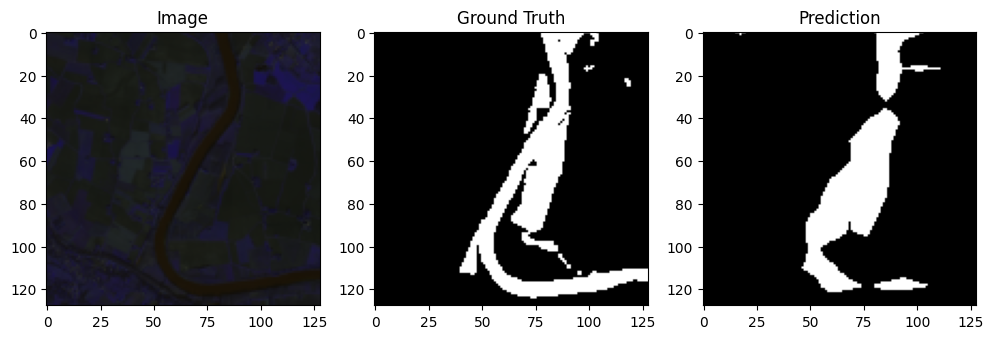

In [21]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(X_val[0][:,:,2:5])  # RGB bands
plt.title("Image")

plt.subplot(1,3,2)
plt.imshow(Y_val[0].squeeze(), cmap='gray')
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(pred_mask[0][0], cmap='gray')
plt.title("Prediction")

plt.show()